# KNMI Neerslagdata downloaden
Dit notebook haalt dagelijkse neerslaggegevens op van alle KNMI neerslagstations voor de periode 1950 t/m 2026.

**Benodigde packages:**
```
!pip install requests pandas
```

## 1: Packages importeren
- `requests` stuurt verzoeken naar de KNMI-server  
- `pandas` verwerkt de data in een tabel (DataFrame)  
- `re` voor regular expressions (*regex*)

In [17]:
import time
import requests
import pandas as pd
import re

## 2: Instellingen
Hier stel je in welke jaren je wilt downloaden en van welke URL.

In [29]:
URL       = "https://www.daggegevens.knmi.nl/klimatologie/monv/reeksen" # reeksen ipv daggegevens!
STARTJAAR = 1950
EINDJAAR  = 2026

## 3: Data downloaden
De KNMI-server geeft een HTML-foutpagina terug als je te veel data in één keer opvraagt.  
Daarom vragen we de data **per half jaar** op (jan–jun en jul–dec).

We definiëren twee hulpfuncties:
- `maak_periodes` — geeft een lijst van (start, eind) datumkoppels
- `download_chunk` — downloadt één periode en geeft een DataFrame terug.

In [25]:
alle_jaren = []

jaren = pd.date_range(f"{STARTJAAR}0101", f"{EINDJAAR}0101", freq="6MS").strftime("%Y%m%d").to_list()
periodes = list(zip(jaren[:-1], jaren[1:]))

for start, eind in periodes:
    params = {
        "start": start,
        "end":   eind,
        "stns":  "ALL",
        "vars":  "RD",
        "fmt":   "csv",
    }
    response = requests.post(URL, timeout=120, data=params)

    if "<!DOCTYPE html>" in response.text:
        continue

    regels = [[v.strip() for v in r.split(",")] for r in response.text.splitlines() if not r.startswith("#") and r.strip()]

    df_chunk = pd.DataFrame(regels, columns=["STN", "YYYYMMDD", "RD"])
    alle_jaren.append(df_chunk)
    print(f"{start} → {eind}: {len(df_chunk):,} rijen")

    time.sleep(0.2)

## 4: Alle jaren samenvoegen
`pd.concat` plakt alle losse jaarlijkse DataFrames aan elkaar tot één groot **Pandas DataFrame**.

In [39]:
df = pd.concat(alle_jaren, ignore_index=True)
print(f"Totaal aantal rijen: {len(df):,}")

Totaal aantal rijen: 8,797,048


## 5: Kolommen opschonen
- De datum staat nog als getal (bijv. `19500101`) — we zetten dit om naar een echte datum
- RD staat in **tiende millimeters** — deel door 10 voor millimeters
- We sorteren op station en datum

## 6: Stationnamen opzoeken

De KNMI-data gebruikt **stationnummers** (zoals `260` voor De Bilt). Om de grafiek leesbaarder te maken, zoeken we de bijbehorende namen op. We doen één extra verzoek aan de KNMI-server en lezen de commentaarregels uit (die beginnen met `#`).

In [40]:
df["YYYYMMDD"] = pd.to_datetime(df["YYYYMMDD"], format="%Y%m%d")
df = df.rename(columns={"YYYYMMDD": "datum"})
df["RD"] = pd.to_numeric(df["RD"], errors="coerce")
df = df.sort_values(["STN", "datum"]).reset_index(drop=True)

df.head(10)

,STN,datum,RD
0,10,1950-01-01,0.0
1,10,1950-01-02,32.0
2,10,1950-01-03,57.0
3,10,1950-01-04,26.0
4,10,1950-01-05,57.0
5,10,1950-01-06,83.0
6,10,1950-01-07,26.0
7,10,1950-01-08,12.0
8,10,1950-01-09,0.0
9,10,1950-01-10,0.0


## 7: Opslaan als CSV
CSV is leesbaar in Excel en elke teksteditor.  
Nadeel: groot bestand, en datatypes (zoals datum) gaan verloren.

In [10]:
df.to_csv("knmi_neerslag.csv", index=False)
print("Opgeslagen als knmi_neerslag.csv")

Opgeslagen als knmi_neerslag.csv


## 8: Grafiek maken

### A: Data laden

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pad = "/Users/hbraakmann/Desktop/KNMI_project/knmi_neerslag.csv"
df = pd.read_csv(pad)
df["datum"] = pd.to_datetime(df["datum"]) #converteren naar datetime object

### B: Data filteren

In [3]:
dag_max = df.groupby("datum")["RD"].max().reset_index()
zware_dagen = dag_max.loc[dag_max["RD"] > 500]
data = zware_dagen.groupby(zware_dagen["datum"].dt.year)["RD"].count().reset_index()
data.columns = ["jaar", "aantal_dagen"]

In [13]:
data.head(3)

,jaar,aantal_dagen
0,1950,11
1,1951,5
2,1952,7


### C: Data plotten

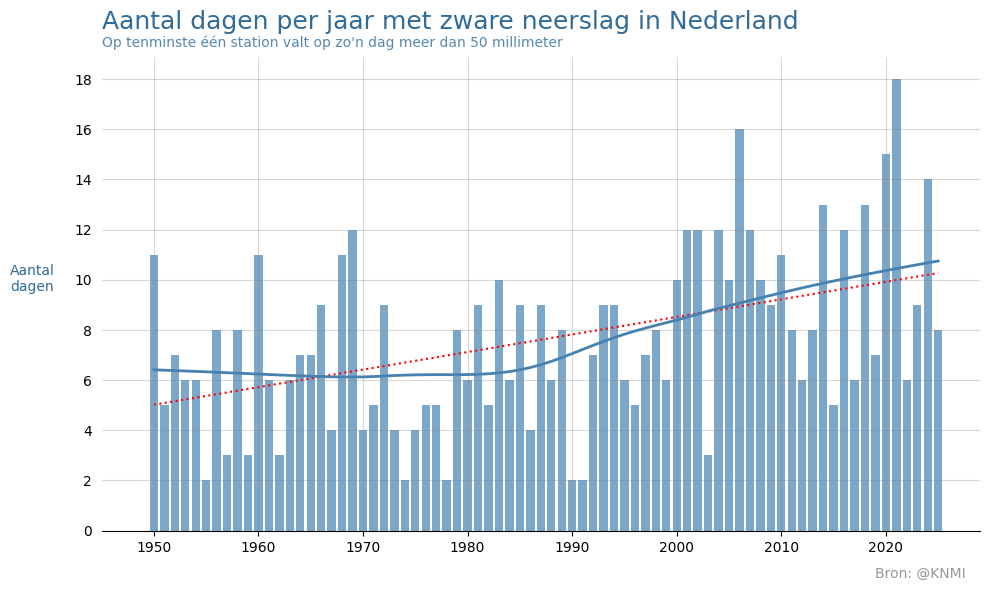

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

trend_low = lowess(data["aantal_dagen"], data["jaar"], frac=0.6)

coef = np.polyfit(data["jaar"], data["aantal_dagen"], deg=1)
trend = np.poly1d(coef)
fig, ax = plt.subplots(figsize=(10,6))

ax.bar(data["jaar"], data["aantal_dagen"], color="#7DA7C9")
ax.plot(data["jaar"], trend(data["jaar"]), color="red",linestyle=":", zorder=1)
ax.plot(trend_low[:, 0], trend_low[:, 1], color="#4681AF", linewidth=2, zorder=2)

ax.set_title("Aantal dagen per jaar met zware neerslag in Nederland", color="#306B99", fontsize=18, pad=20, loc="left")
ax.text(0, 1.02, "Op tenminste één station valt op zo'n dag meer dan 50 millimeter", transform=ax.transAxes, 
             fontsize=10, color="#306B99", alpha=0.8)
ax.set_ylabel("Aantal\ndagen", color="#306B99", rotation=0, labelpad=30)
ax.set_yticks(range(0, 20, 2))
ax.set_xlim(1945, 2029)
ax.grid(axis="both", color="grey", alpha=0.3, zorder=0)
ax.tick_params(axis="y", width=0)

ax.spines[["left", "top", "right"]].set_visible(False)
ax.text(0.88, -0.1, "Bron: @KNMI", transform = ax.transAxes, color="grey", alpha=0.8)
plt.tight_layout()
plt.show()